# Quantum Color Image Edge Detection — 4x4 Simulation

Implementation of *Quantum color image edge detection algorithm based on Sobel operator* (Yuan et al. 2025), with the storage scheme from ref. [13] (median-filtering paper).

Pipeline:
1. OCQR neighborhood encoding (Eq. 6) via row-by-row info-transfer with 4 reusable ancillas (Algorithm 1 of ref. [13]).
2. Gradient calculation U_G (Fig. 13).
3. Max-value module QC (Fig. 10).
4. Threshold U_T (Fig. 11).
5. Edge subtraction (Fig. 14).

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))

from qiskit import transpile, QuantumCircuit
from qiskit_aer import AerSimulator

from helpers.ocqr_encoding import (
    prepare_test_matrix_4x4,
    prepare_neighborhood_images,
    decode_ocqr_to_classical,
    convert_3bit_to_8bit,
    convert_8bit_to_3bit,
    get_3bit_to_8bit_lut,
    get_8bit_to_3bit_lut,
)
from helpers.quantum_modules import (
    quantum_adder,
    quantum_subtractor,
    quantum_comparator,
)
from helpers.sobel_edge_detection import (
    classical_sobel_gradients,
    classical_edge_detection,
    build_edge_detection_circuit,
    print_circuit_details,
)

## 1. Paper's 4x4 test matrix (Fig. 1)

In [2]:
test_matrix = prepare_test_matrix_4x4()
print('R channel:'); print(test_matrix[:, :, 0])
print('G channel:'); print(test_matrix[:, :, 1])
print('B channel:'); print(test_matrix[:, :, 2])

R channel:
[[1 2 2 0]
 [3 3 2 3]
 [4 2 7 3]
 [3 3 0 0]]
G channel:
[[2 3 6 7]
 [5 4 4 7]
 [7 6 7 5]
 [7 5 7 2]]
B channel:
[[1 2 0 2]
 [0 1 2 5]
 [4 1 7 5]
 [5 0 2 0]]


## 2. Classical reference

Computes the four Sobel gradients in software, picks `G_max = max(|G_x|, |G_y|, |G_{45}|, |G_{135}|)`, applies the threshold per Fig. 11 (edge: G' := 2^q-1; non-edge: G' := G_max), and subtracts G' from the original image.

Threshold T = 2^(q-1) = 4
Max gradient |G_max| (R):
[[11 11 10  9]
 [10 11 13 19]
 [10  3  7 16]
 [11 15 19 17]]
Classical edge image (R):
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
Classical edge image (G):
[[0 0 0 0]
 [0 0 0 0]
 [0 0 5 0]
 [0 0 0 0]]
Classical edge image (B):
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]


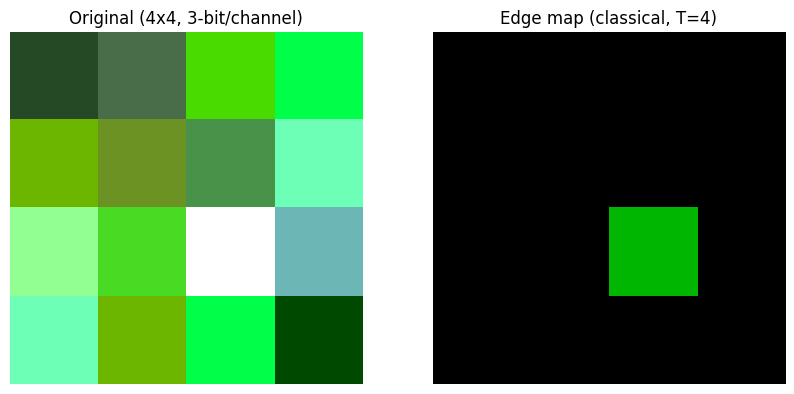

In [4]:
edge_img, max_grad, thresh = classical_edge_detection(test_matrix)
print(f'Threshold T = 2^(q-1) = {thresh}')
print('Max gradient |G_max| (R):'); print(max_grad[:, :, 0])
print('Classical edge image (R):'); print(edge_img[:, :, 0])
print('Classical edge image (G):'); print(edge_img[:, :, 1])
print('Classical edge image (B):'); print(edge_img[:, :, 2])

os.makedirs('./images/output', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(convert_3bit_to_8bit(test_matrix))
axes[0].set_title('Original (4x4, 3-bit/channel)')
axes[0].axis('off')
axes[1].imshow(convert_3bit_to_8bit(edge_img))
axes[1].set_title(f'Edge map (classical, T={thresh})')
axes[1].axis('off')
fig.savefig('./images/output/edge_detection_4x4_lut.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Build the quantum edge-detection circuit

In [11]:
n, q = 2, 3
qc = build_edge_detection_circuit(test_matrix, n=n, q=q)
print_circuit_details(qc, n=n, q=q)

QUANTUM EDGE DETECTION CIRCUIT (paper-faithful)
Image size : 4 x 4
Depth bits : q = 3 (intensity range [0, 7])
Threshold  : T = 2^(q-1) = 4

Qubit breakdown:
  pos         :   4 qubits
  ch          :   2 qubits
  I0          :   3 qubits
  I1          :   3 qubits
  I2          :   3 qubits
  I3          :   3 qubits
  I4          :   3 qubits
  I5          :   3 qubits
  I6          :   3 qubits
  I7          :   3 qubits
  I8          :   3 qubits
  aux         :  20 qubits
  TOTAL       :  53 qubits

Depth      : 628
Total gates: 1181
  cx        : 510
  x         : 238
  ccx       : 197
  reset     : 185
  HalfAdder : 24
  cswap     : 12
  measure   : 9
  h         : 6

Paper qubit budget (n=2, q=3): 53
Ours: 53  (match)


## 4. Transpile and inspect gate counts

Per Sect. 3.3 the paper counts a Toffoli (CCX) as 5 elementary gates and a controlled-swap (CSWAP) as 15 elementary gates. The 'Elementary' total below uses that convention.

In [12]:
sim = AerSimulator(method='extended_stabilizer')
tqc = transpile(qc, sim, optimization_level=3)
print(f'Transpiled qubits: {tqc.num_qubits}')
print(f'Transpiled depth : {tqc.depth()}')
ops = dict(tqc.count_ops())
total = sum(ops.values())
print(f'Total gates      : {total}')
print('Gate breakdown:')
for g, c in sorted(ops.items(), key=lambda kv: -kv[1]):
    print(f'  {g:10s}: {c}')

weights = {'ccx': 5, 'cswap': 15}
elem = sum(c * weights.get(g, 1) for g, c in ops.items() if g not in ('measure', 'reset'))
print(f"\nElementary count (paper convention, excluding measure/reset): {elem}")
print(f"Paper's edge-extraction-only theoretical (Sect. 3.3): 365q - 24 = {365 * q - 24} for q={q}")

Transpiled qubits: 53
Transpiled depth : 862
Total gates      : 1587
Gate breakdown:
  cx        : 839
  ccx       : 358
  x         : 190
  reset     : 185
  measure   : 9
  h         : 6

Elementary count (paper convention, excluding measure/reset): 2825
Paper's edge-extraction-only theoretical (Sect. 3.3): 365q - 24 = 1071 for q=3


In [10]:
qc = qc.decompose()
print_circuit_details(qc, n=n, q=q)

QUANTUM EDGE DETECTION CIRCUIT (paper-faithful)
Image size : 4 x 4
Depth bits : q = 3 (intensity range [0, 7])
Threshold  : T = 2^(q-1) = 4

Qubit breakdown:
  pos         :   4 qubits
  ch          :   2 qubits
  I0          :   3 qubits
  I1          :   3 qubits
  I2          :   3 qubits
  I3          :   3 qubits
  I4          :   3 qubits
  I5          :   3 qubits
  I6          :   3 qubits
  I7          :   3 qubits
  I8          :   3 qubits
  aux         :  20 qubits
  TOTAL       :  53 qubits

Depth      : 2096
Total gates: 4461
  cx        : 2015
  t         : 788
  tdg       : 591
  h         : 394
  u         : 244
  reset     : 185
  ccx       : 154
  x         : 70
  mcx       : 11
  measure   : 9

Paper qubit budget (n=2, q=3): 53
Ours: 53  (match)


## 5. Run on the extended-stabilizer simulator

Local-laptop note: with ~60 qubits and many Toffolis, the local `extended_stabilizer` backend may OOM on WSL with 8 GB RAM. The paper used IBM Q's `simulator_extended_stabilizer` backend (63-qubit support, large RAM). If the cell below OOMs, run remotely.

In [7]:
try:
    res = sim.run(tqc, shots=256, seed_simulator=42).result().get_counts()
    recovered = decode_ocqr_to_classical(res, n=n, q=q)
    print('Recovered R channel:'); print(recovered[:, :, 0])
    print('Recovered G channel:'); print(recovered[:, :, 1])
    print('Recovered B channel:'); print(recovered[:, :, 2])
    print('Match R:', np.array_equal(recovered[:, :, 0], edge_img[:, :, 0]))
    print('Match G:', np.array_equal(recovered[:, :, 1], edge_img[:, :, 1]))
    print('Match B:', np.array_equal(recovered[:, :, 2], edge_img[:, :, 2]))
except Exception as exc:
    print('Local simulation failed (likely OOM):')
    print(' ', type(exc).__name__, str(exc)[:200])
    print('Run on IBM Q simulator_extended_stabilizer for the full result.')

Simulation failed and returned the following error message:
ERROR:  [Experiment 0] a circuit requires more memory than max_memory_mb.


Local simulation failed (likely OOM):
  QiskitError 'ERROR:  [Experiment 0] a circuit requires more memory than max_memory_mb. ,  ERROR: a circuit requires more memory than max_memory_mb.'
Run on IBM Q simulator_extended_stabilizer for the full result.


## 6. Per-module unit tests

Quick re-verification of ADD, SUB, CMP on all 8x8 input combinations for q=3. These reproduce the standalone checks in `helpers/quantum_modules.py`.

In [8]:
sim_small = AerSimulator()
q_ = 3

def run_test(gate, layout, golden):
    n_qb = layout(q_)
    fails = 0
    for a in range(1 << q_):
        for b in range(1 << q_):
            qc = QuantumCircuit(n_qb, n_qb)
            for i, bit in enumerate(format(a, f'0{q_}b')[::-1]):
                if bit == '1': qc.x(i)
            for i, bit in enumerate(format(b, f'0{q_}b')[::-1]):
                if bit == '1': qc.x(q_ + i)
            qc.append(gate(q_), list(range(n_qb)))
            qc.measure(range(n_qb), range(n_qb))
            tqc_ = transpile(qc, sim_small)
            res = sim_small.run(tqc_, shots=1).result().get_counts()
            out = list(res.keys())[0].replace(' ', '')[::-1]
            if not golden(a, b, out, q_):
                fails += 1
    return fails

def add_golden(a, b, out, q_):
    # New ADD layout: a[q] + b[q] + carry[1] = 2q+1 qubits
    # HalfAdderGate semantics: sum overwrites B (qubits q..2q-1), A preserved.
    a_out = int(out[:q_][::-1], 2)
    b_out = int(out[q_:2*q_][::-1], 2)
    carry = int(out[2*q_])
    return (a_out == a) and (b_out + (carry << q_) == a + b)

def sub_golden(a, b, out, q_):
    # New SUB layout: a[q] + b[q] + borrow[1] = 2q+1 qubits
    # SUB semantics: result := A - B mod 2^q overwrites A; B preserved; borrow=1 iff A<B
    a_out = int(out[:q_][::-1], 2)
    b_out = int(out[q_:2*q_][::-1], 2)
    borrow = int(out[2*q_])
    return (b_out == b) and (a_out == (a - b) % (1 << q_)) and (borrow == (1 if a < b else 0))

def cmp_golden(a, b, out, q_):
    # New CMP layout: a[q] + b[q] + bo[1] + cout[1] = 2q+2 qubits
    a_out = int(out[:q_][::-1], 2)
    b_out = int(out[q_:2*q_][::-1], 2)
    bo = int(out[2*q_])
    cout = int(out[2*q_+1])
    return a_out == a and b_out == b and bo == 0 and cout == (1 if a < b else 0)

print('ADD:', run_test(quantum_adder, lambda q: 2*q + 1, add_golden), '/ 64 fails')
print('SUB:', run_test(quantum_subtractor, lambda q: 2*q + 1, sub_golden), '/ 64 fails')
print('CMP:', run_test(quantum_comparator, lambda q: 2*q + 2, cmp_golden), '/ 64 fails')

ADD: 0 / 64 fails
SUB: 0 / 64 fails
CMP: 0 / 64 fails
